In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

In [2]:
df = pd.read_csv('Advertising.csv')
df.head(6)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
5,8.7,48.9,75.0,7.2


In [3]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [4]:
pd.DataFrame(df.isnull().sum(), columns =["Count of Null Values"]).T

,TV,Radio,Newspaper,Sales
Count of Null Values,0,0,0,0


In [5]:
X = df[['TV']]

In [6]:
Y = df['Sales']

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, random_state=50)

In [8]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train.values, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.06]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.89
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[1113.42]


In [9]:
b0 = round(model.intercept_,2)
b1 = round(model.coef_[0],2)

print('Intercept (b0):', b0)
print('Coefficient (b1):', b1)

Intercept (b0): 6.89
Coefficient (b1): 0.06


In [10]:
Tv_advertisment = [[120]]

pred = model.predict(Tv_advertisment)
print("prediction= ", pred[0])

prediction=  13.695422045001305


In [11]:
Tv_advertisment

[[120]]

In [12]:
b0 = model.intercept_
b1 = model.coef_[0]
a = Tv_advertisment[0][0]
pred2 = b0 + b1 * a
print("prediction = ", pred2)

prediction =  13.695422045001305


In [13]:
Y_pred = model.predict(X_test.values)

In [14]:
Y_pred

array([16.85430492, 20.18899637,  8.23968537, 14.22851898, 12.34566599,
       19.27592609, 20.05288651,  7.37765629, 19.82036551, 11.89763771,
       20.48957229, 16.9280311 , 19.18518619, 16.67282512, 21.79962965,
       14.55745113, 13.75213448, 19.83737924,  9.32856421, 14.35895759,
       13.11695516, 11.160376  , 10.42311429, 19.50277585, 22.41212399,
       10.76906017, 12.01673384, 12.31730977, 17.37605937, 18.61806179,
       13.87123061, 15.38545274,  7.84836953, 18.09630735, 11.22275968,
        9.42497535, 12.71429684, 21.78828716, 11.83525403, 11.22275968])

In [15]:
diff = pd.DataFrame({'Actual':Y_test,'Predicted':Y_pred})
diff.head(10)

,Actual,Predicted
112,17.1,16.854305
165,16.9,20.188996
12,9.2,8.239685
73,11.0,14.228519
144,12.3,12.345666
20,18.0,19.275926
199,18.4,20.052887
8,4.8,7.377656
39,21.5,19.820366
88,12.9,11.897638


In [16]:
from sklearn import metrics
import numpy as np

mae = metrics.mean_absolute_error(Y_test,Y_pred)
mse = metrics.mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(metrics.mean_squared_error(Y_test,Y_pred))

In [18]:
print('mae =', round(mae, 2))
print('mse =', round(mse, 2))
print('rmse =', round(rmse, 2))

mae = 1.74
mse = 4.66
rmse = 2.16


<Axes: xlabel='Sales'>

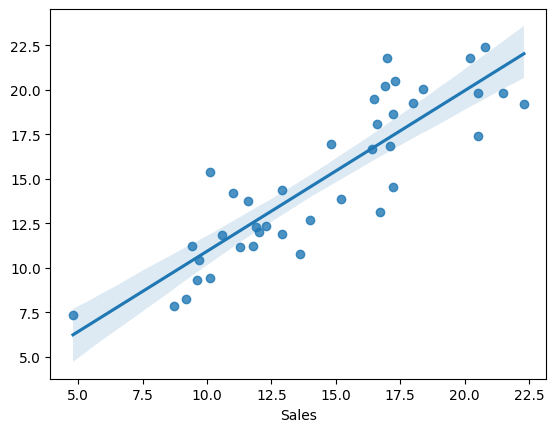

In [19]:
sns.regplot(x = Y_test, y = Y_pred)